## 05. Cluster Profiling & Final Customer Segmentation

### Objective

The previous notebook (`04_clustering_experiments.ipynb`) evaluated multiple
feature representations and clustering algorithms using:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Score
- Visualization
- Cluster Size Distributions

The experiments identified **Robust + PCA (3)** as the leading representation,
while the final number of clusters was intentionally left undecided.

This notebook moves from **clustering experiments to business interpretation**.

The objectives are to:

1. Load the selected clustering representation.
2. Compare candidate values of K.
3. Analyze cluster sizes.
4. Profile clusters using the original behavioral features.
6. Select the final number of clusters.
7. Assign evidence-based business personas.
8. Recommend business actions.
9. Save the final segmentation and reusable model artifacts.

**Important principle**

The final value of K will **not** be selected from a single metric.

The decision will combine:

> Internal validation + stability + cluster size + behavioral separation + business interpretability.

### Import Required Libraries

In [22]:
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from sklearn.decomposition import PCA

### Load Customer-Level Behavioral Features

The clustering algorithm was trained on transformed representations.

However, cluster interpretation should be performed using the **original
customer-level behavioral features**.

This allows us to answer questions such as:

- Which cluster spends the most?
- Which cluster purchases most frequently?
- Which customers are most recent?
- Which customers buy the widest variety of products?
- Which groups have higher cancellation rates?

This is much more interpretable than describing customers using PCA components.

In [23]:
customer_df = pd.read_csv('../data/processed/customer_df.csv', index_col='Customer ID')

print(f'Customers: {customer_df.shape[0]:,}')
print(f'Features : {customer_df.shape[1]}')
print(f'Missing  : {customer_df.isnull().sum().sum()}')

display(customer_df.head())

Customers: 5,878
Features : 11
Missing  : 0


,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
Customer ID,,,,,,,,,,,
12346,77556.46,12,74285,27,326.117361,400.060417,6463.038333,6190.416667,0.027427,0.000,0.294118
12347,4921.53,8,2967,126,2.873611,402.063889,615.191250,370.875000,0.017367,0.125,0.000000
12348,2019.40,5,2714,25,75.984028,362.926389,403.880000,542.800000,0.010991,0.200,0.000000
12349,4428.69,4,1624,138,19.124306,570.854861,1107.172500,406.000000,0.005246,0.000,0.200000
12350,334.40,1,197,17,310.867361,0.000000,334.400000,197.000000,0.000000,0.000,0.000000


### Load the Selected Representation from Notebook 04

Notebook 04 identified:

> **Robust + PCA (3)**

as the leading clustering representation.

This notebook therefore uses the same representation when evaluating the
candidate K values.

The original clustering experiments compared Standard-scaled features,
Robust-scaled features, and PCA representations. The Robust + PCA (3)
representation was selected as the leading candidate because it produced
strong overall clustering structure.

In [24]:
X_robust = pd.read_csv("../data/processed/X_robust.csv",index_col="Customer ID")

pca_3 = PCA(n_components=3,random_state=42)

X_selected = pd.DataFrame(
    pca_3.fit_transform(X_robust),
    index=X_robust.index,
    columns=["PC1", "PC2", "PC3"]
)

print('Selected representation: Robust + PCA (3)')
print('Shape:', X_selected.shape)

display(X_selected.head())

Selected representation: Robust + PCA (3)
Shape: (5878, 3)


,PC1,PC2,PC3
Customer ID,,,
12346,5.442786,-0.187602,2.858658
12347,1.976727,0.244608,0.185569
12348,1.145901,0.510056,0.697643
12349,2.218576,-0.530110,0.855837
12350,-0.768407,-1.005582,1.126833


### Candidate Values of K

***Notebook 04*** indicated that K=2 achieved the strongest Silhouette Score,
but also noted that K=2 may produce a segmentation that is too coarse.

Therefore, the most relevant candidates are:

- K = 2
- K = 3
- K = 5
- K = 6

In [25]:
candidate_ks = [2, 3, 5, 6]

candidate_models = {}
candidate_labels = {}
candidate_results = []

for k in candidate_ks:

    model = KMeans(n_clusters=k,random_state=42,n_init=20)

    labels = model.fit_predict(X_selected)

    candidate_models[k] = model
    candidate_labels[k] = labels

    candidate_results.append({
        "K": k,
        "Silhouette": silhouette_score(X_selected, labels),
        "Davies-Bouldin": davies_bouldin_score(X_selected, labels),
        "Calinski-Harabasz": calinski_harabasz_score(
            X_selected,
            labels
        )
    })

candidate_metrics = pd.DataFrame(candidate_results)

display(candidate_metrics.round(4))

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.4766,0.8823,2768.5339
1,3,0.3772,0.9118,4105.5113
2,5,0.3355,0.9436,3701.0823
3,6,0.3241,0.9309,3607.0997


### Cluster Size Analysis Across Candidate K Values

Cluster size is important because a segmentation should produce groups that
are large enough to understand and act upon.

However:

> **A small cluster is not automatically a bad cluster.**

A small group may represent a strategically important customer segment.

We therefore inspect the size distribution for every candidate K.

In [26]:
candidate_profiles = {}

for k in candidate_ks:

    profile = customer_df.copy()

    profile["Cluster"] = candidate_labels[k]

    candidate_profiles[k] = profile

    print(f"K={k}:")
    print(
        profile["Cluster"]
        .value_counts()
        .sort_index()
        .to_dict()
    )
    print()

K=2:
{0: 5154, 1: 724}

K=3:
{0: 2409, 1: 696, 2: 2773}

K=5:
{0: 374, 1: 1993, 2: 1102, 3: 887, 4: 1522}

K=6:
{0: 987, 1: 1298, 2: 334, 3: 714, 4: 1323, 5: 1222}



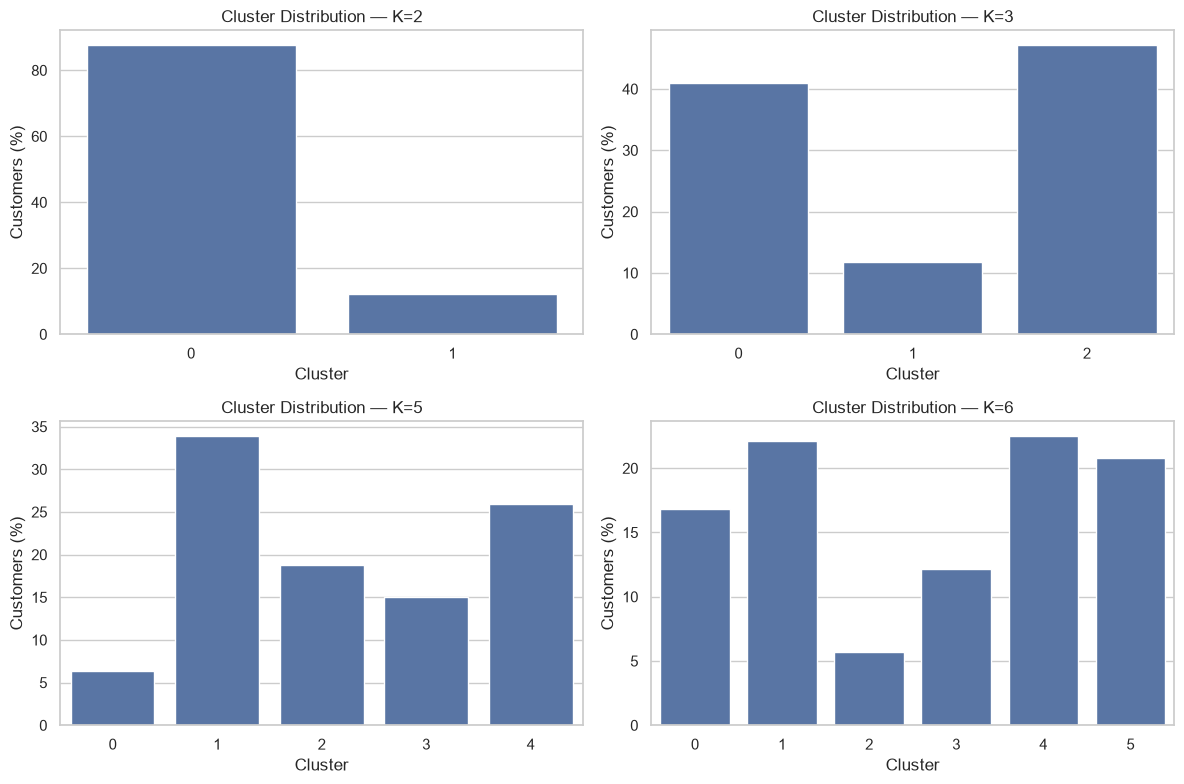

In [27]:
records = []
for k, labels in candidate_labels.items():
    shares = pd.Series(labels).value_counts(normalize=True) * 100
    for cluster, share in shares.items():
        records.append({"K": k, "Cluster": cluster, "Share_%": round(share, 2)})

cluster_sizes_all = pd.DataFrame(records)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, k in zip(axes.flat, candidate_ks):
    data = cluster_sizes_all[cluster_sizes_all["K"] == k]
    sns.barplot(data=data, x="Cluster", y="Share_%", ax=ax)
    ax.set(title=f"Cluster Distribution — K={k}", ylabel="Customers (%)")

plt.tight_layout()

### Stability Evidence

Higher ARI indicates that the resulting partitions are more consistent across
different initializations.

In [28]:
stability_records = []

seeds = [0, 10, 30, 42, 97]

for k in candidate_ks:

    labels_by_seed = []

    for seed in seeds:

        model = KMeans(n_clusters=k,random_state=seed,n_init=20)
        labels = model.fit_predict(X_selected)
        labels_by_seed.append(labels)

    ari_scores = []

    for i in range(len(labels_by_seed)):

        for j in range(i + 1, len(labels_by_seed)):

            ari_scores.append(
                adjusted_rand_score(
                    labels_by_seed[i],
                    labels_by_seed[j]
                )
            )

    stability_records.append({
        "K": k,
        "ARI_Mean": np.mean(ari_scores),
        "ARI_Std": np.std(ari_scores),
        "ARI_Min": np.min(ari_scores),
        "ARI_Max": np.max(ari_scores),
    })

stability_df = pd.DataFrame(stability_records)

stability_df.round(4)

,K,ARI_Mean,ARI_Std,ARI_Min,ARI_Max
0,2,1.0000,0.0000,1.0000,1.0000
1,3,0.9969,0.0019,0.9932,0.9994
2,5,0.9914,0.0064,0.9839,1.0000
3,6,0.9644,0.0182,0.9403,0.9903


### Cluster Medians for Each Candidate K

Because many customer behavioral variables are highly right-skewed, medians
are particularly useful for describing the typical customer.

We will inspect the median profile for each candidate K.

In [29]:
candidate_medians = {}

for k, profile in candidate_profiles.items():

    medians = (
        profile
        .groupby("Cluster")[customer_df.columns]
        .median()
    )

    candidate_medians[k] = medians

    print('\n', 'k =',k)
    display(medians.round(3))


 k = 2


,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
Cluster,,,,,,,,,,,
0,940.89,3.0,522.0,45.0,89.499,235.974,286.252,158.292,0.009,0.00,0.0
1,536.51,2.0,309.0,42.0,164.039,111.025,232.218,127.625,0.007,0.75,0.0



 k = 3


,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
Cluster,,,,,,,,,,,
0,333.180,1.0,182.0,19.0,284.965,0.000,187.925,99.000,0.000,0.00,0.000
1,506.795,2.0,298.0,40.5,174.049,104.920,228.270,124.183,0.007,0.78,0.000
2,2280.510,6.0,1380.0,92.0,43.087,464.275,372.425,227.000,0.015,0.00,0.143



 k = 5


,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
Cluster,,,,,,,,,,,
0,354.480,1.0,187.5,27.0,299.886,0.000,214.112,117.000,0.000,1.000,0.000
1,692.850,2.0,396.0,35.0,178.931,95.047,310.185,181.000,0.005,0.000,0.000
2,171.275,1.0,84.0,10.0,372.094,0.000,126.015,58.000,0.000,0.000,0.000
3,1131.750,4.0,631.0,60.0,71.892,363.997,243.515,132.500,0.012,0.333,0.000
4,4142.430,11.0,2399.5,138.0,28.828,586.948,406.902,248.917,0.019,0.053,0.167



 k = 6


,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
Cluster,,,,,,,,,,,
0,159.170,1.0,75.0,9.0,387.049,0.000,127.000,59.000,0.000,0.000,0.000
1,4712.380,11.0,2787.0,148.0,25.870,593.464,440.562,271.523,0.020,0.066,0.167
2,317.250,1.0,166.0,25.0,376.905,0.000,212.212,114.000,0.000,1.000,0.000
3,1160.165,4.0,655.0,64.0,71.987,354.446,270.799,144.325,0.012,0.500,0.000
4,957.530,4.0,520.0,51.0,65.858,366.077,213.080,114.222,0.013,0.000,0.000
5,592.100,1.0,350.5,29.0,274.965,0.000,388.502,242.167,0.000,0.000,0.000


### Final K Selection

The final K should be selected using the evidence collected throughout this
notebook.

### Selection criteria

| Criterion | Importance |
|---|---|
| Internal validation | High |
| Stability | High |
| Behavioral separation | Very High |
| Cluster size | Medium |
| Interpretability | Very High |
| Business usefulness | Very High |
| Segmentation complexity | Medium |

### Decision principle

A candidate K should be preferred when it:

1. Maintains good internal clustering quality.
2. Is stable across different initializations.
3. Produces clearly different behavioral profiles.
4. Avoids unnecessary fragmentation.
5. Produces segments that can support different business actions.

Do not automatically select the K with the highest Silhouette Score.

In [30]:
optimal_k = 3
customer_df["Cluster"] = candidate_labels[optimal_k]

cluster_medians = customer_df.groupby("Cluster").median().round(2)

print(f'\n--- K={optimal_k} ---')
display(cluster_medians.T)


--- K=3 ---


Cluster,0,1,2
Monetary,333.18,506.80,2280.51
Frequency,1.00,2.00,6.00
TotalItemsPurchased,182.00,298.00,1380.00
UniqueProducts,19.00,40.50,92.00
Recency,284.96,174.05,43.09
CustomerLifetime,0.00,104.92,464.28
AverageOrderValue,187.92,228.27,372.42
AverageItemsPerOrder,99.00,124.18,227.00
PurchaseRate,0.00,0.01,0.02
WeekendPurchaseRatio,0.00,0.78,0.00


### Final Clustering Model

After selecting the final K, we fit the final K-Means model on the selected
representation:

> RobustScaler + PCA(3)

**The resulting labels will become the final customer segmentation.**

In [31]:
optimal_model = KMeans(n_clusters=optimal_k,random_state=42, n_init=20)
final_labels = optimal_model.fit_predict(X_selected)

final_customer_df = customer_df.copy()
final_customer_df["Cluster"] = final_labels

final_cluster_sizes = (
    final_customer_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .to_frame()
)

final_cluster_sizes["Share_%"] = (
    final_cluster_sizes["Customers"]
    / len(final_customer_df)
    * 100
)

final_cluster_sizes.round(2)

,Customers,Share_%
Cluster,,
0,2409,40.98
1,696,11.84
2,2773,47.18


### Final Cluster Boxplots

The following visualizations focus on the most important behavioral variables.

Because several features are strongly right-skewed, a logarithmic y-axis is
used where appropriate.

The purpose is to visually verify the differences identified in the summary
statistics.

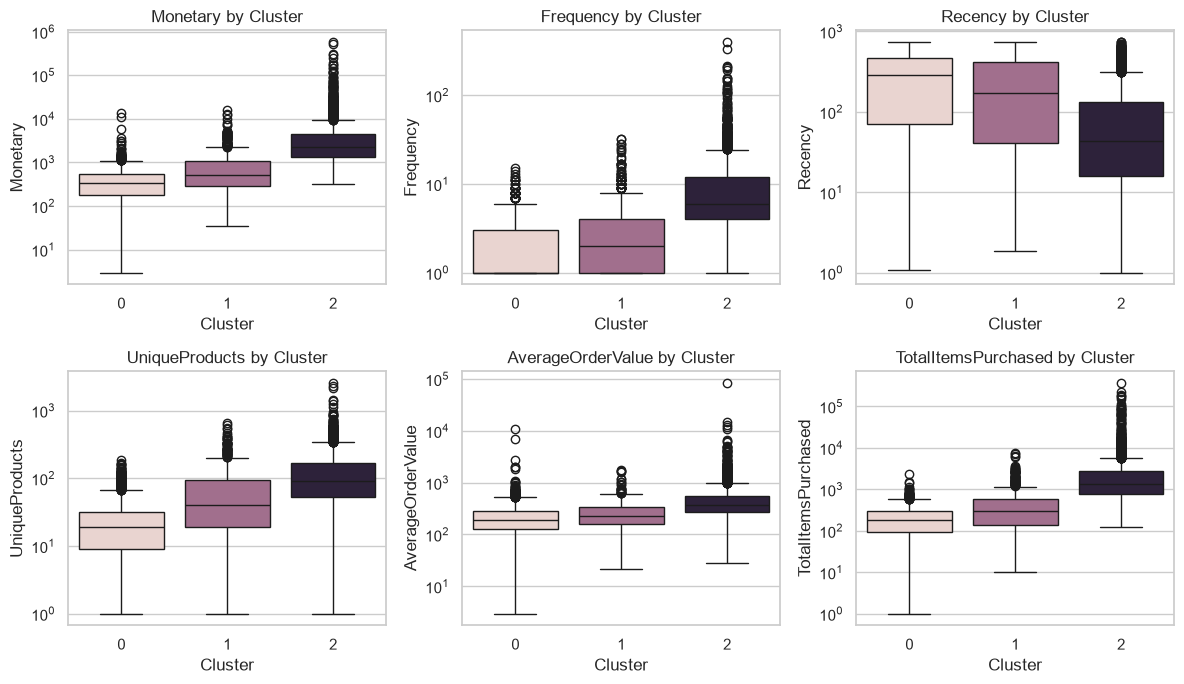

In [32]:
features = ["Monetary", "Frequency", "Recency", "UniqueProducts", "AverageOrderValue","TotalItemsPurchased"]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, feature in zip(axes.flat, features):
    sns.boxplot(
        data=final_customer_df, 
        x="Cluster", 
        y=feature, 
        ax=ax, 
        hue="Cluster", 
        legend=False
    )
    
    if (final_customer_df[feature] > 0).all():
        ax.set_yscale("log")
        
    ax.set(title=f"{feature} by Cluster")

plt.tight_layout()

### Artifact Serialization and Data Export

In this final step, we persist our dimensionality reduction transformer, trained clustering model, and final segmented customer dataset to disk. Serializing these artifacts ensures reproducibility and allows downstream applications to load pre-computed labels and apply predictions to new data without re-running the training pipeline:

* **`pca.joblib`**: The fitted PCA transformer used to reduce original features into 3 principal components.
* **`clustering_model.joblib`**: The trained K-Means model containing cluster centers and fitted labels.
* **`final_customer_segmentation.csv`**: The fully processed customer dataset containing all behavioral metrics alongside their final assigned `Cluster` labels.

In [33]:
joblib.dump(pca_3,"../models/pca.joblib")
joblib.dump(optimal_model,"../models/clustering_model.joblib")

final_customer_df.to_csv('../data/processed/final_customer_segmentation.csv', index=True)

### Final Business Personas and Recommended Actions

Based on the medians extracted for our K=3 clustering, we can clearly define the following customer segments and strategic actions:

* **Cluster 0 (The One-Offs)**
  * **Profile:** Lowest frequency (1.0), zero customer lifetime, and high recency (284 days).
  * **Recommended Action:** Deploy automated re-engagement campaigns, targeted win-back discounts, or post-purchase surveys to identify friction points preventing a second purchase.

* **Cluster 1 (The Casual Weekenders)**
  * **Profile:** Moderate monetary value with a highly dominant `WeekendPurchaseRatio` (0.78).
  * **Recommended Action:** Optimize marketing cadence by targeting this group with Friday-evening email campaigns, weekend-exclusive promotions, and limited-time weekend flash sales.

* **Cluster 2 (The Loyal High-Rollers)**
  * **Profile:** Highest frequency (6.0), lowest recency (43 days), and highest monetary value (2286.19). *Note: Displays a slightly elevated cancellation rate (0.14).*
  * **Recommended Action:** Invite to VIP loyalty programs, offer early access to new inventory, and assign premium proactive customer support to mitigate the higher cancellation risk.